# MTH/CMSE 314
# IC14: Least Squares problems
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Understanding how a least squares problem can be solved using linear algebra.
- Solving a data based least squares fit problem.
- (Optional) Understanding the matrix pseudoinverse and its relationship with least squares fit.

<img alt="image showing a 3D vector projected onto a 2D plane" src="https://lh5.googleusercontent.com/RFgtgkULxOPzUC8lwl1j265FjpzaD2YIDHjy94VyqOOU7xIQf03bsHDSmxYNOmYDXeLPn7iMTg=w740" width="35%">
</p>


#### Please read the following before you begin: 

- <font color=#641e16> We recommended that you complete the After-Class Assignments (ACs) before starting the In-Class Assignments (ICs),
    
- <font color=#641e16> Keep your lecture notes handy for easy reference.

- <font color=#641e16> Use class time to collaborate with your group and get help from instructors, as IC solutions will not be provided.

----

##  Review: Least squares solution

Let $Ax = y$ be a system of $m$ linear equations in $n$ variables. A *least squares solution* of $Ax = y$ is an solution $\hat{x}$ in $R^n$ such that:

$$ \min_{\hat{x}}\|y - A\hat{x}\|.$$

Note we substitute $y$ for our typical variable $b$ here because we will use $b$ later to represent the intercept to a line and we want to try and avoid confusion in notation. It also consistent with the picture above. 

In other words, $\hat{x}$ is a value of $x$ for which $Ax$ is as close as possible to $y$. From previous lectures, we know this to be true if the vector $$y - A\hat{x}$$ is orthogonal (perpendicular) to the column space of $A$.

We also know that the dot product is zero if two vectors are orthogonal. So we have  
$$a \cdot (Ax - y)  = 0, $$
for all vectors $a$ in the column spaces of $A$.

The columns of $A$ span the column space of $A$. Denote the columns of $A$ as 
$$A = [a_1, \cdots, a_n].$$ 
Then we have 
$$a_1^\top (Ax - y)  = 0, \\ a_2^\top(Ax-y)=0\\\vdots \\a_n^\top(Ax-y)=0.$$
It is the same as taking the transpose of $A$ and doing a matrix multiply:
$$A^\top (Ax - y) = 0.$$

That is:

<font size=5>$$A^\top Ax = A^\top y$$</font>

The above equation is called the *least squares solution* to the original equation $Ax=y$.  The matrix $A^\top A$ is symmetric and invertable. Then solving for $\hat{x}$ can be calculated as follows:

$$\hat{x} = (A^\top A)^{-1}A^\top y$$


The matrix $(A^\top A)^{-1}A^\top$ is also called the left inverse.

---
&#9989; <font color=blue>**Do this:** Run the cell below before moving on:

In [1]:
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
import sympy as sym
import time

sym.init_printing(use_unicode=True)

&#9989; <font color=blue>**Do this:** A researcher has conducted experiments of a particular Hormone dosage in a population of rats. The table shows the number of fatalities at each dosage level tested. Determine the least squares line and use it to predict the number of rat fatalities at hormone dosage of 22. 

| Hormone level  | 20 | 25 | 30 | 35 | 40 | 45 | 50  |
|---|---|---|---|---|---|---|---|
| Fatalities | 101 | 115 | 92 | 64 | 60 | 50 | 49| 


Text(0, 0.5, 'Fatalities')

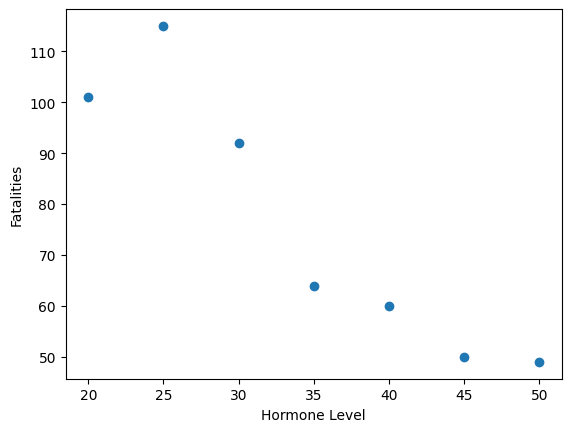

In [2]:
# Make a scatterplot of dataset
H = [20,25,30,35,40,45,50]
f = [101,115, 92,64,60,50,49]

plt.scatter(H,f)
plt.xlabel('Hormone Level')
plt.ylabel('Fatalities')

We want to determine a linear model that is expressed by the following equation 

$$f = a + bH,$$

to approximate the connection between Hormone dosage ($H$) and Fatalities $f$. 
That is, we want to find $a$ (y-intercept) and $b$ (slope) for this line. First we define the variable $ 
x = \left[
\begin{matrix}
    a  \\
    b  
\end{matrix}
\right] 
$ as the column vector that needs to be solved. Then, we need to convert the overdetermined system of equations $$a + bH_0 = f_0$$ $$a + bH_1 = f_1$$ $$\vdots$$ $$a + bH_6 = f_6$$ into matrix form $$Ax = y.$$

&#9989; <font color=blue>**Do this:** Rewrite the above system of equations in matrix form $Ax=y$ by defining your ```numpy``` matrices ```A``` and ```y``` using the data from above.

In [55]:
# put your code here
coef = np.ones((7,1))
A = np.hstack((coef, np.matrix(H).T))
y = np.matrix(f).T

&#9989; <font color=blue>**Do this:** Calculate the square matrix $A^\top A$ (Call it ```AtA```) and the modified right hand side vector as $A^\top y$ (Call it ```Aty```):

In [43]:
# put your code here
AtA = A.T @ A
Aty = A.T @ y

&#9989; <font color=blue>**Do this:** Find the *least squares solution* by solving $A^\top Ax=A^\top y$ for $x$.

In [44]:
# put your code here
x = np.linalg.inv(AtA) @ Aty
x

matrix([[155.35714286],
        [ -2.27142857]])

&#9989; <font color=blue>**Do this:** Given the solution you just obtained above, store the two scalars, y-intercept and slope, as ```a``` and ```b``` respectively.

In [51]:
# put your code here
a = x[0,0]
b = x[1,0]

&#9989; <font color=blue>**Do this:** Run this block of code below. The code will plot the original data and the linear model whose coefficients we found by performing a least squares fit.

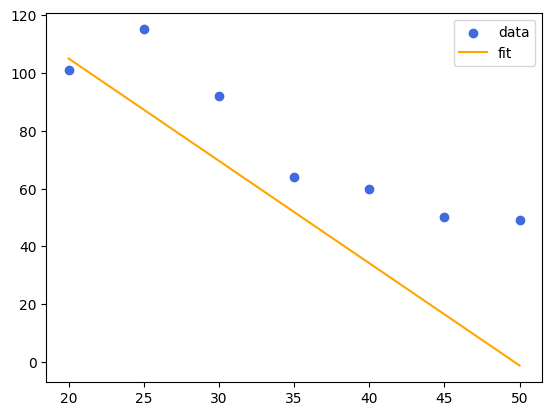

In [74]:
H = [20,25,30,35,40,45,50]
f = [101,115, 92,64,60,50,49]
plt.scatter(H,f, color="royalblue", label="data")

H2 = np.linspace(np.min(H), np.max(H))

f2 = a + b*H2

plt.plot(H2, f2, color="orange", label="fit")
plt.legend()

plt.show()

&#9989; <font color=blue>**Do this:** Now, let's fit a quadratic model instead of a linear model to our data, i.e. $$a + bH + c H^2 = f$$ 

<font color=blue> To do this, the vector of unknowns is now $x = \begin{bmatrix}a\\b\\c\end{bmatrix}$, and the overdetermined system of equations is $$a + bH_0 + cH_0^2 = f_0$$ $$a + bH_1 + cH_1^2 = f_1$$ $$\vdots$$ $$a + bH_6 + cH_6^2= f_6$$

<font color=blue> Again, put this system of equations into matrix form $Ax = y$, solve $A^\top Ax = A^\top y$ to find the least squares solution for $x$, and then extract the coefficients $a$, $b$, and $c$ for your model.

In [73]:
# put your code here
coef = np.ones((7,1))
A = np.hstack((coef, np.matrix(H).T, np.matrix(np.array(H)**2).T))
y = np.matrix(f).T

AtA = A.T @ A
Aty = A.T @ y

x = np.linalg.inv(AtA) @ Aty

a = x[0,0]
b = x[1,0]
c = x[2,0]

&#9989; <font color=blue>**Do this:** Now, plot the original data along with the curve for the quadratic model $f = a+bH+cH^2$ whose coefficients we found by performing the least squares fit. 

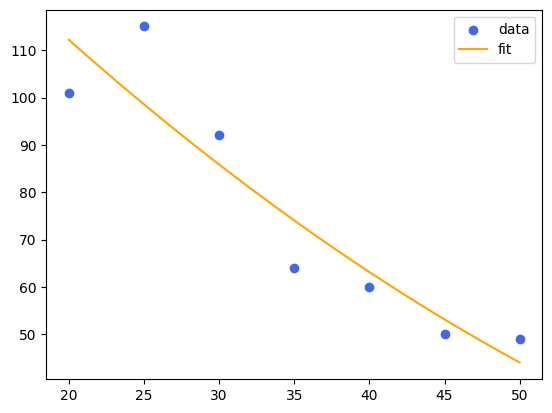

In [75]:
H = [20,25,30,35,40,45,50]
f = [101,115, 92,64,60,50,49]
plt.scatter(H,f, color="royalblue", label="data")

H2 = np.linspace(np.min(H), np.max(H))

f2 = a + b*H2 + c*H2**2

plt.plot(H2, f2, color="orange", label="fit")
plt.legend()

plt.show()

&#9989; <font color=blue>**Do this:** Now, see if you can generalize your code above to fit a degree-$d$ polynomial model $$x_0 + x_1H + x_2H^2 + \cdots + x_dH^d = f$$ for some coefficients $x_0,x_1,x_2,\ldots,x_d$, where $3 \le d \le 6$. Again, you should first put the system of equations into matrix form, then find the least squares solution, and finally make a plot showing the original data and the curve for the polynomial model.

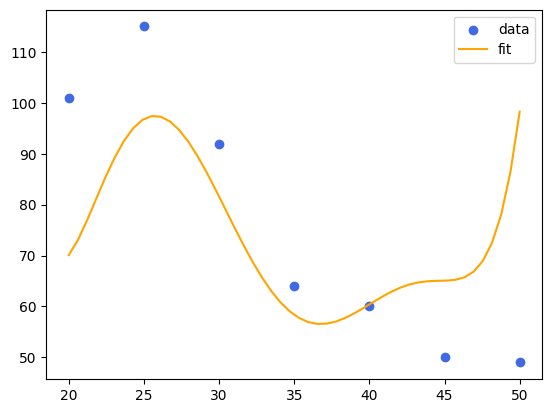

In [130]:
# put your code here
d = 7

H = [20,25,30,35,40,45,50]
f = [101,115, 92,64,60,50,49]

A = np.ones((7,1))
for i in range(1, d+1):
    A = np.hstack((A, np.matrix(np.array(H)**i).T))
    
y = np.matrix(f).T

AtA = A.T @ A
Aty = A.T @ y

x = np.linalg.inv(AtA) @ Aty

plt.scatter(H,f, color="royalblue", label="data")

H2 = np.linspace(np.min(H), np.max(H))

f2 = 0
for j in range(d+1):
    f2 += (x[j,0] * H2**j)

plt.plot(H2, f2, color="orange", label="fit")
plt.legend()

plt.show()

&#9989; <font color=blue>**Do this:** The interactive function below allows you to adjust the degree of the polynomial model as well as the limits of the $x$-axis in the plot. Play with the interactive function below by adjusting the degree of the least-squares fit approximation and extending the `x_min` and `x_max` parameters. Do you think that an eighth-order polynomial is a good model for this dataset? Why or why not?

interactive(children=(IntSlider(value=20, description='x_min', max=20, min=10), IntSlider(value=50, descriptio…

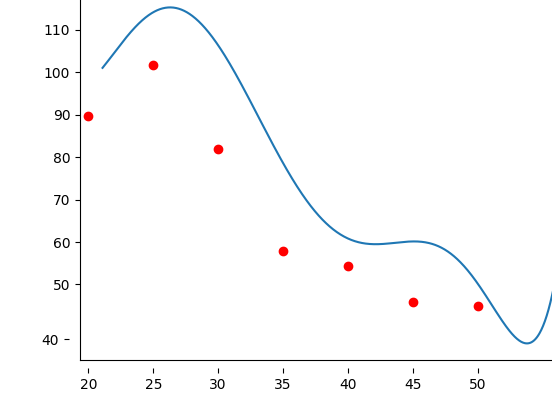

In [124]:
from ipywidgets import interact, fixed
import ipywidgets as widgets

@interact(x=fixed(H), y=fixed(f), degree=widgets.IntSlider(min=1, max=8, step=1, value=8), x_min=widgets.IntSlider(min=min(H)-10, max=min(H), step=1, value=min(H)), x_max=widgets.IntSlider(min=max(H), max=max(H)+10, step=1, value=max(H)))
def graphPolyN(x, y, x_min, x_max, degree):
    p = np.polyfit(x, y, degree)
    f = np.poly1d(p)
    
    x_pred = np.linspace(x_min, x_max, 1000)
    y_pred = f(x_pred)
    
    plt.scatter(x, y, color="red")
    plt.plot(x_pred, y_pred)
    
    

No, an eighth degree polynomial is no a good fit for this data. This is too many degrees for the limited amount of data that we are using, and because of this the resulting least-squares curve is noticeably off from our data. I'm not exactly sure what the relationship between number of data points and number of degrees for the polynomial fit is, but there most likely is one, as shown by the good curve fit for 1-6 degrees that drops off tremendously at any function of order past that. 

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? You need to submit this file in `.pdf` format. To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.
- If this fails, save it as a pdf and merge it with this pdf, perhaps using an online tool (google it!)

- Please double check the contents of the file. One of the most common errors students make is submission of an empty file!